In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd

# 1. Load and Validate Data 
df = pd.read_csv("datasets.csv")

# Align column names used elsewhere in this notebook
df = df.rename(columns={
    "Disaster Type": "incidentType",
    "State": "state",
})

# Ensure state column consistency (abbreviation format)
df["state"] = df["state"].astype(str).str.upper().str.strip()

# Drop rows with missing state values
df = df.dropna(subset=["state"])

# Map state abbreviations to full state names
state_abbrev_to_name = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming",
}

df["state_name"] = df["state"].map(state_abbrev_to_name).fillna(df["state"])


### Data Preparation
Load the Milestone 2 dataset and standardize state columns for geospatial analysis.


In [2]:

# 2. State-Level Aggregation

state_counts = df.groupby(["state", "state_name"]).size().reset_index(name="DisasterCount")

# 3. State + Incident Type Aggregation

state_incident_counts = df.groupby(["state", "state_name", "incidentType"]).size().reset_index(name="Count")


### Aggregation
Create summary tables for total state declarations and state + incident type counts.


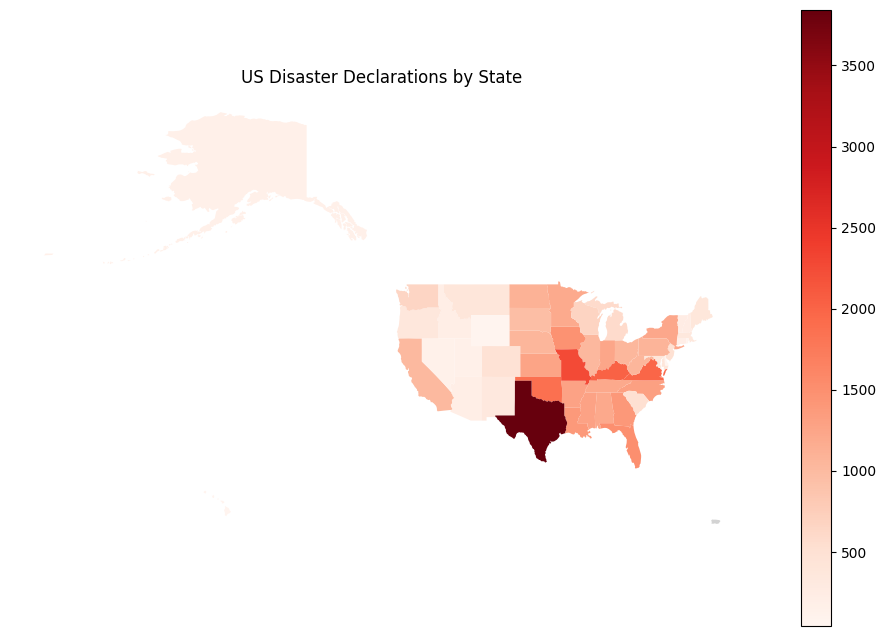

In [3]:

# 4. Choropleth Map (State-level)

# Load a US states GeoJSON from a public source
us_states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)

# Merge with disaster counts by state name
choropleth_data = us_states.merge(
    state_counts,
    left_on="name",
    right_on="state_name",
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
choropleth_data.plot(column="DisasterCount", cmap="Reds", legend=True, ax=ax, missing_kwds={"color": "lightgrey"})
plt.title("US Disaster Declarations by State")
plt.axis("off")
plt.show()


### Choropleth Map
Show disaster declaration counts by state on a geographic map.


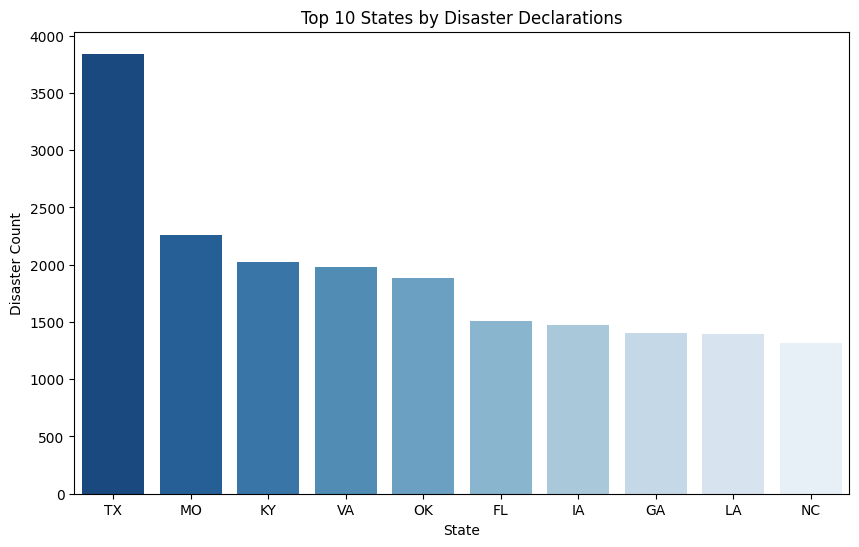

In [4]:

# 5. State Comparison Bar Chart

top_states = state_counts.sort_values(by="DisasterCount", ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Seaborn is deprecating passing `palette` without `hue`; set hue to x and disable the legend
sns.barplot(x="state", y="DisasterCount", data=top_states, hue="state", palette="Blues_r", legend=False)
plt.title("Top 10 States by Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Disaster Count")
plt.show()


### Top States Bar Chart
Plot the top 10 states by disaster declaration count.


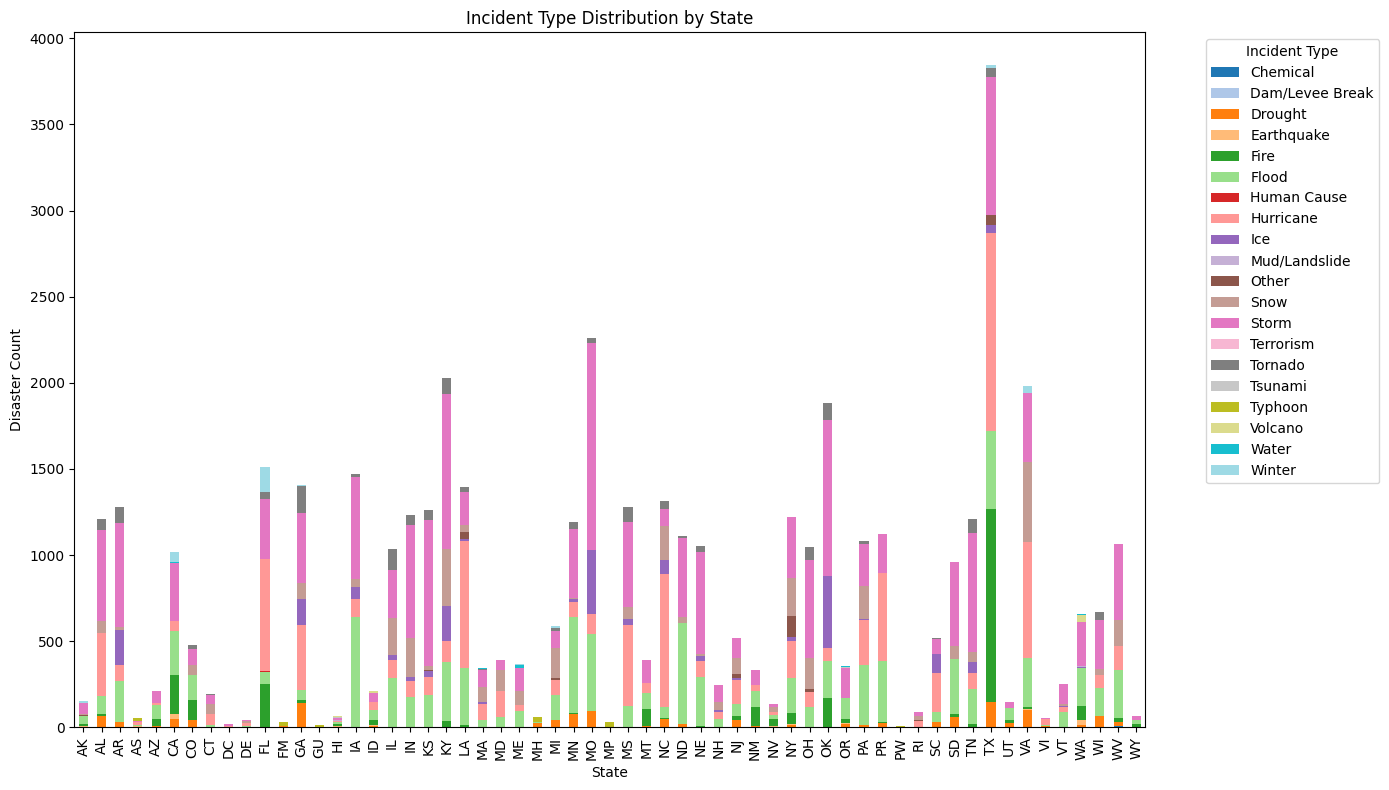

In [ ]:

# 6. Incident Type Distribution by State 

incident_pivot = state_incident_counts.pivot(index="state", columns="incidentType", values="Count").fillna(0)

incident_pivot.plot(kind="bar", stacked=True, figsize=(14, 8), colormap="tab20")
plt.title("Incident Type Distribution by State")
plt.xlabel("State")
plt.ylabel("Disaster Count")
plt.legend(title="Incident Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Incident Type Distribution
Compare how disaster types contribute to counts across states.


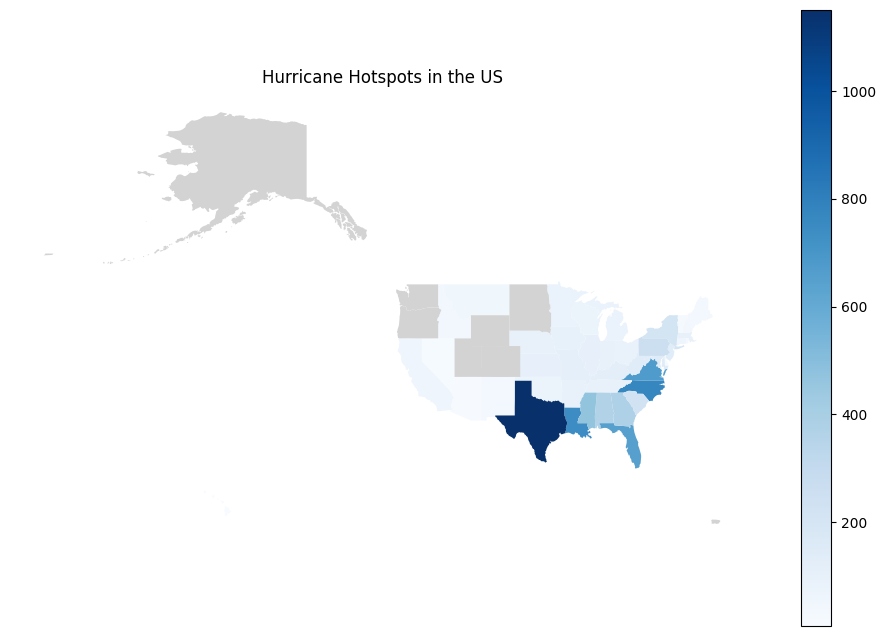

In [ ]:

# 7. Incident Type Hotspot Maps 

hurricane_data = state_incident_counts[state_incident_counts["incidentType"] == "Hurricane"]

choropleth_hurricane = us_states.merge(
    hurricane_data,
    left_on="name",
    right_on="state_name",
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
choropleth_hurricane.plot(column="Count", cmap="Blues", legend=True, ax=ax, missing_kwds={"color": "lightgrey"})
plt.title("Hurricane Hotspots in the US")
plt.axis("off")
plt.show()


### Hurricane Hotspots
Highlight states with the most hurricane declarations.


In [ ]:

# 8. Interactive Map with Plotly

fig = px.choropleth(
    state_counts,
    locations="state",
    locationmode="USA-states",
    color="DisasterCount",
    scope="usa",
    color_continuous_scale="Reds",
    title="Interactive Choropleth of US Disaster Declarations",
)
fig.show()
